# Colormaps and style

{mod}`snaplab_tools.plotting.utils` supplies the style defaults, the lab palette, a set of diverging colormaps, as well as a way to *measure* whether a colour choice
is color-blind friendly.

In [1]:
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt

from snaplab_tools.datasets import make_spatial_map
from snaplab_tools.plotting.utils import (
    cvd_min_delta_e,
    get_snap_colors,
    make_diverging_cmap,
    make_sequential_cmap,
    register_custom_colormaps,
    set_plotting_params,
    show_colormaps,
)

set_plotting_params()

## One call at the top of the notebook

{func}`~snaplab_tools.plotting.utils.set_plotting_params` applies seaborn's `paper`/`white` theme
and then the handful of rcParams that are helpful for exporting paper-ready figures.

In [2]:
for key in ['font.size', 'pdf.fonttype', 'ps.fonttype', 'svg.fonttype', 'savefig.format']:
    print(f'{key:16s} {plt.rcParams[key]}')

font.size        8.0
pdf.fonttype     42
ps.fonttype      42
svg.fonttype     none
savefig.format   png


The two font settings are the ones you will be glad for at submission. `fonttype = 42` embeds
Type-42 fonts in PDF and PS output and `svg.fonttype = 'none'` leaves SVG text as text, so labels
stay selectable and editable in Illustrator rather than arriving as outlines you cannot fix.

The 8pt base size is the other half: it is chosen for a figure printed at column width, not for a
figure read on a laptop, so text stays legible after the panel is scaled down. Pass `format='pdf'`
if you would rather `savefig` default to vector output.

:::{warning}
Call it *after* any `seaborn.set_theme()` of your own, not before. `set_theme()` rewrites rcParams
wholesale, so a later call silently replaces the 8pt size with seaborn's own default.
:::

## A useful colour palette

{func}`~snaplab_tools.plotting.utils.get_snap_colors` returns the palette as a name → RGB dict,
normalised to 0–1 so it drops straight into matplotlib.

In [3]:
colors = get_snap_colors()

for name, rgb in colors.items():
    print(f'{name:20s} {mpl.colors.to_hex(rgb)}')

raspberry_blush      #ea5651
starry_night_blue    #304179
north_sea_green      #006f74
conch_shell          #eebaa9
cinnamon             #a54a36
wenge                #3f2c29
savannah_green       #c29e3e
new_age              #d9ced1


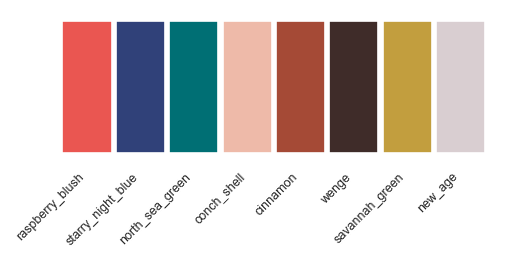

In [4]:
fig, ax = plt.subplots(figsize=(4, 1.2), dpi=150)
ax.bar(range(len(colors)), 1, color=list(colors.values()), width=0.92)
ax.set_xticks(range(len(colors)))
ax.set_xticklabels(colors, rotation=45, ha='right', fontsize=6)
ax.set_yticks([])
for side in ax.spines.values():
    side.set_visible(False)
plt.show()

The first three are a useful categorical set. `cat_trio=True`
returns just those, and `as_list=True` gives values without names, which is the form
`sns.set_palette` and most `color=` arguments want.

The remaining five are extra/supporting colours if you need more options.

In [5]:
trio = get_snap_colors(cat_trio=True)
print(list(trio))
print(get_snap_colors(cat_trio=True, as_list=True))

['raspberry_blush', 'starry_night_blue', 'north_sea_green']
[[0.9176470588235294, 0.33725490196078434, 0.3176470588235294], [0.18823529411764706, 0.2549019607843137, 0.4745098039215686], [0.0, 0.43529411764705883, 0.4549019607843137]]


## Measuring a palette instead of trusting it

{func}`~snaplab_tools.plotting.utils.cvd_min_delta_e` simulates protanopia, deuteranopia and
tritanopia (Machado 2009, full severity), converts each simulated pair into perceptually uniform
OKLab, and returns the **worst** of the three distances (scaled by ×100). One number, and it is a lower bound:
whichever kind of colour blindness a reader has, the two colours are at least this far apart.

As a rule of thumb: **≥ 8** is the floor for two colours that must stay distinguishable, 15–25 is
comfortable, and 30+ is very robust.

In [6]:
for (name_a, a), (name_b, b) in itertools.combinations(trio.items(), 2):
    print(f'{name_a:20s} vs {name_b:20s}  dE = {cvd_min_delta_e(a, b):5.1f}')

print()
print(f"matplotlib's default red vs green   dE = {cvd_min_delta_e('#d62728', '#2ca02c'):5.1f}")

raspberry_blush      vs starry_night_blue     dE =  21.5
raspberry_blush      vs north_sea_green       dE =   8.1
starry_night_blue    vs north_sea_green       dE =  12.2

matplotlib's default red vs green   dE =   3.9


The categorical trio clears the floor on every pair, with raspberry vs green the tightest at 8.1 —
usable, but borderline. Compare that with the first two colours of matplotlib's default cycle used
together, at 3.9: to someone with red-green color blindness (deuteranopia) those are the same colour. That comparison is the entire
argument for checking, because red and green look maximally different to everyone else in the room.

The check also tells you which pairs *not* to avoid. For example, two of the colours in our pallette are nearly indistinguishable under simulation:

In [7]:
worst = min(
    (cvd_min_delta_e(a, b), name_a, name_b)
    for (name_a, a), (name_b, b) in itertools.combinations(colors.items(), 2)
)
print(f'closest pair in the full palette: {worst[1]} / {worst[2]}, dE = {worst[0]:.1f}')

closest pair in the full palette: conch_shell / new_age, dE = 5.1


## The diverging presets

{func}`~snaplab_tools.plotting.utils.register_custom_colormaps` builds the presets and registers
them with matplotlib, so `cmap='snap_...'` works anywhere a colormap name is accepted — including
inside third-party functions. You can call it at the top of every figure notebook.

['snap_navy_gold', 'snap_indigo_gold', 'snap_purple_orange', 'snap_sydnor_sa', 'snap_blue_orange', 'snap_blue_vermillion', 'snap_blue_red', 'snap_blue_brown', 'snap_blue_pink']


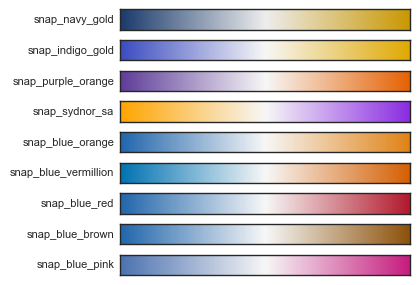

In [8]:
presets = register_custom_colormaps()
print(list(presets))

show_colormaps()
plt.show()

Three things are true of every map in the above list, and are the reasons to prefer them over reaching
for `RdBu_r`:

**The midpoint is a neutral grey.** A diverging map encodes sign, so zero must look like nothing.
Put a hue in the middle and it reads as a third category — demonstrated below.

**The two poles are vetted.** Each pair was chosen to hold up under colour-vision simulation, and
you can verify that yourself, since a registered colormap will hand you its own endpoints:

In [9]:
for name in presets:
    cmap = mpl.colormaps[name]
    print(f'{name:22s} dE = {cvd_min_delta_e(cmap(0.0), cmap(1.0)):5.1f}')

snap_navy_gold         dE =  38.0
snap_indigo_gold       dE =  35.0
snap_purple_orange     dE =  28.5
snap_sydnor_sa         dE =  27.8
snap_blue_orange       dE =  26.7
snap_blue_vermillion   dE =  21.9
snap_blue_red          dE =  21.1
snap_blue_brown        dE =  20.6
snap_blue_pink         dE =  10.2


`snap_navy_gold` and `snap_indigo_gold` are the safest; `snap_blue_pink` sits at the floor. `snap_sydnor_sa` is the
orange→purple convention used for the sensorimotor–association axis.

**The names are prefixed.** Matplotlib's colormap registry is global to the process and first
registration wins, silently. The `snap_` prefix makes them unambiguously ours.
Every map also gets a reversed `snap_..._r` variant, which matplotlib does not create automatically
for custom colormaps.

:::{admonition} Please cite
:class: seealso

Sydnor, V.J., Larsen, B., Bassett, D.S., Alexander-Bloch, A., Fair, D.A., Liston, C., Mackey, A.P.,
Milham, M.P., Pines, A., Roalf, D.R., Seidlitz, J., Xu, T., Raznahan, A., & Satterthwaite, T.D.
(2021). Neurodevelopment of the association cortices: Patterns, mechanisms, and implications for
psychopathology. *Neuron*, 109(18), 2820–2846. <https://doi.org/10.1016/j.neuron.2021.06.016>
:::

## Why the midpoint has to be neutral

{func}`~snaplab_tools.plotting.utils.make_diverging_cmap` takes a `(low, mid, high)` triple, so it
is easy to build the mistake and look at it next to the correct version.

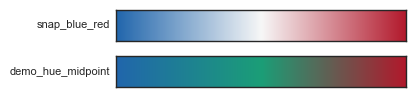

In [10]:
make_diverging_cmap('demo_hue_midpoint', '#2166AC', '#1B9E77', '#B2182B')

show_colormaps(['snap_blue_red', 'demo_hue_midpoint'])
plt.show()

The lower strip has three bands, and the eye finds two edges in it that correspond to nothing in
the data. Values near zero — the ones you most want to read as "no effect" — become the most
visually distinct part of the map. The upper strip fades out at the middle, which is what a
quantity passing through zero actually does.

## On a brain map

Every one of these is just a colormap name, so it goes wherever a name goes.
{func}`~snaplab_tools.plotting.plotting.plot_brain_surface_data` is the usual destination.

:::{note}
This section needs the `surface` extra and the Schaefer `.annot` files — see
[Installation](../installation.md). Nothing else in this tutorial does.
:::

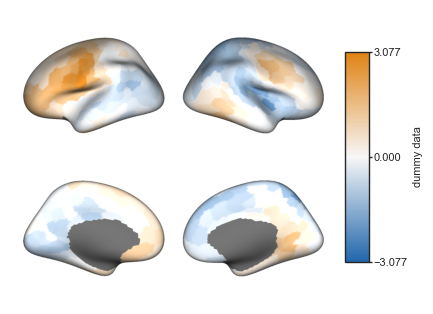

In [11]:
from snaplab_tools.plotting.plotting import plot_brain_surface_data

brain_map = make_spatial_map(n_regions=400, seed=0)

fig, axes = plot_brain_surface_data(
    brain_map, cmap='snap_blue_orange', symmetric_cbar=True,
    cbar_label='dummy data', figsize=(4, 3), alpha=1.0,
)
plt.show()

`alpha=1.0` is worth passing whenever the colours are the point. The default of 0.8 blends the
overlay into the grey surface underneath, which desaturates both poles — the figure shows a mixture
of your colormap and grey rather than your colormap.

`symmetric_cbar=True` is the more consequential one. A diverging colormap puts its neutral point in
the middle of the colour *range*, not at zero, so unless the range is symmetric about zero, grey
lands somewhere else and the figure marks a sign boundary where there is none. Shift the same map
up by 1 and leave the flag off:

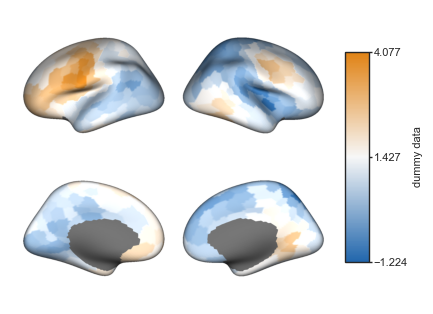

In [12]:
shifted = brain_map + 1.0   # e.g. a map of mostly-positive effect sizes

fig, axes = plot_brain_surface_data(
    shifted, cmap='snap_blue_orange', symmetric_cbar=False,
    cbar_label='dummy data', figsize=(4, 3), alpha=1.0,
)
plt.show()

The cortex is coloured exactly as it was in the previous figure — same parcels, same shades. Only
the colorbar moved: grey now sits at +1.43. Every parcel between 0 and +1.43 is a positive value
being rendered blue, and nothing in the image marks where the sign actually changes. A reader who
takes "blue means negative" for granted (ahem, like Linden does), which is what a diverging map has trained them to do, reads
this figure wrong.

Pass `symmetric_cbar=True` whenever the colormap is diverging, or set `vmin`/`vmax` yourself.

## Sequential maps, for quantities without a sign

A diverging map is the wrong tool when there is no meaningful zero to diverge from — a magnitude, a
count, a distance. {func}`~snaplab_tools.plotting.utils.make_sequential_cmap` builds one from an
ordered list of colours, spread evenly from 0 to 1 (or pass explicit `(position, colour)` tuples).
Light to dark, so that "more" reads as "darker" at a glance and the map still works in greyscale.

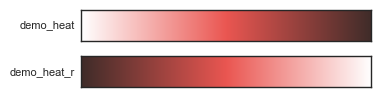

In [13]:
make_sequential_cmap('demo_heat', ['#FFFFFF', '#EA5651', '#3F2C29'])

show_colormaps(['demo_heat', 'demo_heat_r'])
plt.show()

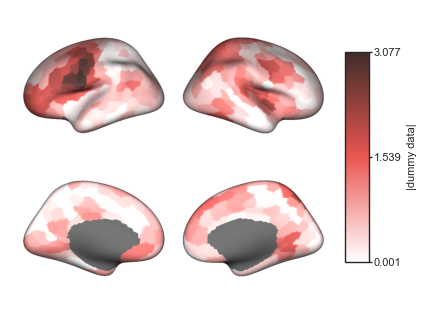

In [14]:
fig, axes = plot_brain_surface_data(
    abs(brain_map), cmap='demo_heat', 
    cbar_label='|dummy data|', figsize=(4, 3), alpha=1.0,
)
plt.show()

## Building your own colour palette

The workflow is: pick the poles, measure them, and only then build the map. Measuring first is the
whole point — a pair can look strikingly different on your screen and be nearly identical to a
colourblind reader.

In [15]:
candidates = {
    'teal / magenta': ('#008080', '#C51B7D'),
    'crimson / green': ('#B2182B', '#1B7837'),
    'teal / gold': ('#00696E', '#C99700'),
}

for label, (low, high) in candidates.items():
    print(f'{label:16s} dE = {cvd_min_delta_e(low, high):5.1f}')

teal / magenta   dE =   2.9
crimson / green  dE =   2.5
teal / gold      dE =  23.4


Teal against magenta fails at 2.9 despite looking like an obvious contrast, and crimson against
green is worse. Teal against gold clears the floor comfortably at 23.4, so that is the one to build
— with a neutral grey in the middle, and a name of your own prefixing so nothing can shadow it.

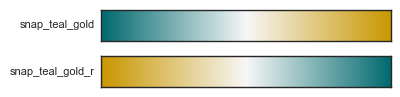

In [16]:
make_diverging_cmap('snap_teal_gold', '#00696E', '#F7F7F7', '#C99700')

show_colormaps(['snap_teal_gold', 'snap_teal_gold_r'])
plt.show()

Pass `register=False` if you only want the colormap object and would rather not add a name to the
global registry — useful inside a library, where a one-off map should not become a side effect of
importing you.

## See also

- {func}`~snaplab_tools.plotting.utils.set_plotting_params` — the style defaults every figure here
  was drawn under
- {func}`~snaplab_tools.plotting.plotting.plot_brain_surface_data` — the surface renderer, and
  `YEO7_COLORS` alongside it for the canonical 7-network categorical colours
- [Plotting correlations](plotting_correlations.ipynb) — where the palette shows up as point
  colours